# Dataset Preparation

**Dataset.**
This project uses the [AG News dataset](https://huggingface.co/datasets/sh0416/ag_news), which consists of short news articles covering diverse contemporary topics, including **World**, **Sports**, **Business**, and **Sci/Tech**.
The dataset was chosen because it contains modern vocabulary from multiple domains, making it suitable for training general-purpose Word2Vec embeddings.

In [1]:
from datasets import load_dataset

dst = load_dataset("sh0416/ag_news")

C:\Users\79635\PycharmProjects\word2vec_scipgram_ns\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
len(dst["train"])

120000

In [3]:
dst["train"]["description"][100000]

" CARACAS, Venezuela (Reuters) - A Venezuelan lawyer  suspected in last week's bombing murder of a top state  prosecutor was killed in a gunfight with police on Tuesday  after he tried to ram detectives with his car and opened fire  on them, officials said."

In [4]:
dst["train"]["title"][100000]

'Venezuelan Car-Bomb Suspect Killed, Weapons Found'

In [5]:
from tqdm import tqdm

In [6]:
number_texts = 15000

**Tokenization and vocabulary construction.**

Each example in the dataset consists of a news title and its corresponding description, which are concatenated into a single text.
The text is then tokenized, and token frequencies are accumulated to build a vocabulary that reflects how often each word appears in the corpus.

In [7]:
from preprocessing import *

word_counts = Counter()

for i in tqdm(range(number_texts)):
    example = dst["train"]["title"][i] + "." + dst["train"]["description"][i]
    tokenization(text=example, word_counts=word_counts)

100%|██████████| 15000/15000 [00:07<00:00, 2023.12it/s]


In [8]:
len(word_counts.keys())

27299

In [9]:
word_counts.most_common(10)

[('the', 26534),
 ('to', 14915),
 ('a', 14000),
 ('of', 12906),
 ('in', 12795),
 ('and', 8846),
 ('on', 7149),
 ('for', 6291),
 ('that', 3339),
 ('with', 3310)]

**Rare word filtering.**

Words that appear only a few times in the corpus are removed, as such tokens are often noisy (e.g., typos or dataset-specific artifacts) and provide limited value for learning reliable word embeddings.
This filtering step helps reduce vocabulary size and improves the stability of the training process.

In [10]:
unique_words = [
    w for w, c in word_counts.items()
    if c > 5
]

In [11]:
len(unique_words)

8777

In [12]:
word2id = {}
id2word = {}

for idx, word in enumerate(unique_words):
    word2id[word] = idx
    id2word[idx] = word

In [13]:
encode_text(text=dst["train"]["title"][100] + "." + dst["train"]["description"][100],
            word2id=word2id,)

[34,
 1318,
 827,
 29,
 1319,
 1320,
 1248,
 162,
 1248,
 162,
 29,
 1319,
 1320,
 614,
 61,
 34,
 816,
 1321,
 61,
 305,
 942,
 61,
 1318,
 944,
 6,
 1322,
 16,
 1323,
 339,
 34,
 88,
 305,
 126,
 939,
 126,
 100,
 1324]

To train the Skip-Gram with Negative Sampling model, the loss function shown above is optimized.
The text is processed using a sliding context window to form positive (center, context) pairs, while negative samples are selected dynamically during training via negative sampling.

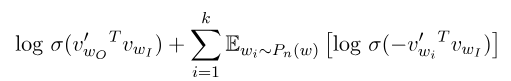

In [15]:
from dataset import *

skipgram_pairs = []
context_window = 2

for i in tqdm(range(number_texts)):
    text = dst["train"]["title"][i] + "." + dst["train"]["description"][i]
    tokens = encode_text(text, word2id=word2id)
    pairs = build_skipgram_pairs(tokens, context_window)
    skipgram_pairs.extend(pairs)

100%|██████████| 15000/15000 [00:10<00:00, 1461.52it/s]


In [16]:
len(dst["train"])

120000

In [17]:
len(skipgram_pairs)

2112596

In [18]:
#update word_counts
#because some words were deleted

word_counts = Counter({
    w: c for w, c in word_counts.items()
    if w in unique_words
})

In [19]:
len(word_counts) == len(unique_words)

True

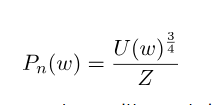

**Negative sampling distribution.**

The negative sampling distribution is defined as the unigram word frequency raised to the power of 0.75 and normalized by a constant
Z.
The function build_unigram_probs implements this formulation by computing the normalized probability distribution used to sample negative words during training.

In [20]:
import numpy as np

def build_unigram_probs(counts: np.ndarray, power: float = 0.75) -> np.ndarray:
    probs = counts ** power
    Z = probs.sum()
    probs /= Z
    return probs

In [21]:
word_counts_array = np.zeros(len(unique_words))

In [22]:
for i in range(len(word_counts_array)):
    current_word = id2word[i]
    freq = word_counts[current_word]
    word_counts_array[i] = freq

In [23]:
probs = build_unigram_probs(word_counts_array)

In [24]:
rng = np.random.default_rng(42)

# Training

In [25]:
from SkipGram_NegativeSampling import *
from training import *

model = Word2VecSGNS(vocab_size = len(unique_words), dim=100)
train(model=model, data=skipgram_pairs, num_epochs=7, k=5, batch_size=128,
      probs=probs, rng=rng)

 14%|█▍        | 1/7 [03:57<23:45, 237.53s/it]

epoch 1: loss=4.1581


 29%|██▊       | 2/7 [15:33<42:15, 507.11s/it]

epoch 2: loss=4.1115


 43%|████▎     | 3/7 [28:58<42:53, 643.29s/it]

...

epoch 5: loss=3.5502


 86%|████████▌ | 6/7 [49:46<07:39, 459.27s/it]

epoch 6: loss=3.4198


100%|██████████| 7/7 [53:41<00:00, 460.18s/it]

epoch 7: loss=3.3091


# Evaluation

**Evaluation.**

For evaluation, a similarity function is used to retrieve the most similar word vectors by computing cosine similarity between embeddings.
Given a query word, the function returns the top-
𝑁
N closest words in the embedding space.

In [26]:
from evaluation import *

get_top_n_similar_words(model, "olympic", word2id, id2word, n=10, use_central=False)

[('first', 0.9735219210082422),
 ('final', 0.9648137372714809),
 ('united', 0.9604482209748657),
 ('city', 0.9568788835259749),
 ("men's", 0.9567546153248346),
 ('games', 0.9561328071100371),
 ('most', 0.95116115373432),
 ('olympics', 0.9491604952159904),
 ('us', 0.9430216649683889),
 ('gold', 0.9422999372769446)]

In [33]:
get_top_n_similar_words(model, "one", word2id, id2word, n=10, use_central=True)

[('us', 0.9950783474663355),
 ('out', 0.9948319986682498),
 ('gold', 0.9948279198947206),
 ('two', 0.994078244979905),
 ('and', 0.9939199765756169),
 ('second', 0.9934917843556529),
 ('first', 0.9921951969059409),
 ('last', 0.9912954734804568),
 ('final', 0.9909659077379016),
 ('athens', 0.9903481250518824)]

In [34]:
get_top_n_similar_words(model, "monday", word2id, id2word, n=10, use_central=False)

[('thursday', 0.9781190256367441),
 ('friday', 0.9761322087661097),
 ('tuesday', 0.9752743866856406),
 ('wednesday', 0.9750473890232012),
 ('said', 0.9067952640354455),
 ('sunday', 0.8248873777090494),
 ('saturday', 0.8016084824739678),
 ('on', 0.7530729980143349),
 ('officials', 0.7193636935509631),
 ('they', 0.6710309046436914)]

As can be seen from the examples above, the model retrieves several semantically related words.

At the same time, not all retrieved neighbors are strictly meaningful from a semantic perspective, which is expected given the simplicity of the model and the limited context and resources.